# Loss comparison — Arm A (elicit) vs Arm B (teach)

Compares the **production runs 5/6 (@500K, completed 2026-07-22)**, with the
OPEN(2) pilots as overlay context, on the loss curves the runs actually log
(spec 00 / spec 02 §11):

- **per-step train loss** (`train_log.jsonl` — pre-update masked loss on each
  incoming batch, all epochs),
- **held-out val loss** (`eval_log.jsonl` — the ε/k stopping evals, every 500 steps),
- **the paper-shaped prequential learning curve** (`logs/prequential.jsonl`,
  epoch-1 only, via `geode.edl.metrics.training_curve`) plus MDL/EDL totals.

Beyond the headline curves: **§1 (training dynamics)** adds train accuracy,
the generalization gap, wall-clock, and gradient-norm views; **§2 (EDL/MDL)**
adds the batch-aligned B−A gap, cumulative codelength vs the ideal code, the
EDL accumulation curve, sample efficiency, normalized EDL (EDL/D, EDL/P), G5
evidence, and scaling with n across the OPEN(2) pilots.

The arms are identical recipes on the identical D_target prefix (500K for the
production runs; the pilots span 10K–500K); they differ only in the parent:
A (run-3 lineage) had the add/sub **algorithm pre-taught** in natural-language
notation, B (run-4 lineage) got **format only**. D_target must therefore only
*elicit* (remap notation) for A but *teach* the algorithm to B.

**Paper-consistent (Donoway et al. EDL):** A starts lower and converges in far
fewer examples; EDL_A ≪ EDL_B; both end near-zero. The paper's absolute numbers
(1B models, ~300K teaching scale) don't transfer to 38.7M — the *qualitative
separation* is what we check. **If the curves overlap, we are in trouble** — see
the reading guide at the bottom.

In [13]:
import json
import os
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# repo root: walk up until we see the geode/ package (same pattern as view_dataset)
here = Path.cwd()
REPO_ROOT = next(
    (p for p in [here, *here.parents] if (p / "geode" / "__init__.py").exists()), None
)
assert REPO_ROOT is not None, "run this notebook from inside the elicit-vs-teach checkout"
sys.path.insert(0, str(REPO_ROOT))

from geode.edl.metrics import (  # noqa: E402
    edl_nats,
    edl_per_label_token,
    edl_per_param,
    mdl_nats,
    nats_to_bits,
    training_curve,
)

LN2 = float(np.log(2))  # nats -> bits for array math; nats_to_bits for scalars

# ---- config: edit these ----
STORE = Path(os.environ.get("GEODE_STORE") or REPO_ROOT / "geode-store")
RUNS = {  # label -> run_id; production runs first so they take the first two colors
    "RUN 5 — Arm A (elicit) @500K": "evt-run5-armA-target",
    "RUN 6 — Arm B (teach) @500K": "evt-run6-armB-target",
    # "pilot A @50K": "evt-run5-pilot-n50k",
    # "pilot B @50K": "evt-run6-pilot-n50k",
    # "pilot B @10K": "evt-run6-pilot-n10k",
    # "pilot B @200K": "evt-run6-pilot-n200k",
    # "pilot B @500K": "evt-run6-pilot-n500k",
}

In [14]:
def read_jsonl(path: Path) -> pd.DataFrame:
    return pd.DataFrame(json.loads(ln) for ln in path.read_text().splitlines() if ln.strip())


runs, rows = {}, []
for label, rid in RUNS.items():
    d = STORE / "runs" / rid
    try:  # logs/prequential.jsonl lands only when the run finishes
        curve = training_curve(rid, store=STORE)
    except FileNotFoundError:
        curve = None
    m = json.loads((d / "manifest.json").read_text())
    res = m["experiment"].get("target_result") or {}
    g5 = (m["experiment"].get("gates") or {}).get("G5") or {}
    tl_path = d / "eval" / "test_loss.json"
    theta_T = (
        json.loads(tl_path.read_text())["loss_per_label_token_nats"] if tl_path.exists() else None
    )
    gs_path = d / "logs" / "gradstats.jsonl"
    runs[label] = {
        "id": rid,
        "train": read_jsonl(d / "train_log.jsonl"),
        "val": read_jsonl(d / "eval_log.jsonl"),
        "grad": read_jsonl(gs_path) if gs_path.exists() else None,
        "curve": curve,
        "result": res,
        "g5": g5,
        "theta_T_nats": theta_T,
    }
    rows.append(
        {
            "run": label,
            "run_id": rid,
            "status": m.get("status"),
            "stop_reason": res.get("stop_reason"),
            "final_step": res.get("final_step"),
            "min_val_bits": None
            if res.get("min_val_nats") is None
            else nats_to_bits(res["min_val_nats"]),
            "theta_T_bits": None if theta_T is None else nats_to_bits(theta_T),
            "G5_zero_shot": g5.get("zero_shot_accuracy"),
        }
    )
pd.DataFrame(rows)

,run,run_id,status,stop_reason,final_step,min_val_bits,theta_T_bits,G5_zero_shot
0,RUN 5 — Arm A (elicit) @500K,evt-run5-armA-target,complete,converged,6000,0.003534,0.002803,0.998047
1,RUN 6 — Arm B (teach) @500K,evt-run6-armB-target,complete,converged,12500,0.033191,0.051332,0.950195


## §1 Training dynamics — the normal comparison

Everything the trainer logs directly: per-step loss and accuracy, held-out val
loss, the generalization gap, wall-clock cost, and gradient norms. These say
*how* each arm trained; §2 says what the training *cost in bits*.

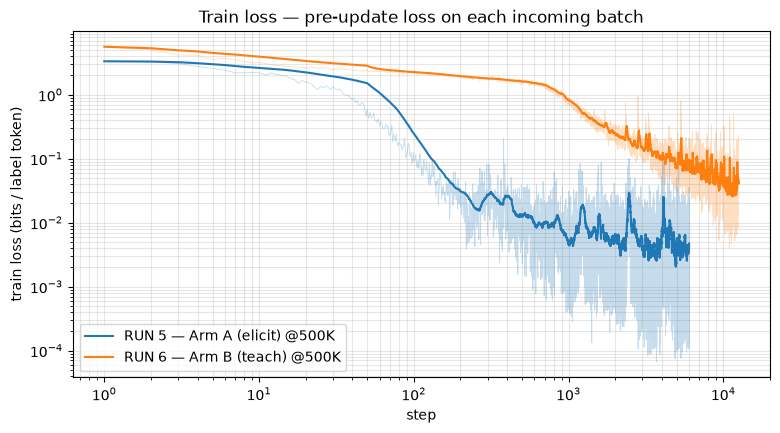

In [15]:
# Per-step train loss (pre-update batch loss, all epochs). The sharp drop after
# ~1 epoch (~390 steps at 50K, batch 128) is data repeating — expected.
# Log-log: both step and loss axes span orders of magnitude.
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
fig, ax = plt.subplots(figsize=(9, 4.5))
for (label, r), color in zip(runs.items(), colors):
    t = r["train"]
    bits = t["train_loss_nats"].map(nats_to_bits)
    ax.plot(t["step"], bits, color=color, alpha=0.25, lw=0.6)
    ax.plot(t["step"], bits.rolling(50, min_periods=1).mean(), color=color, label=label)
ax.set(xlabel="step", ylabel="train loss (bits / label token)",
       xscale="log", yscale="log",
       title="Train loss — pre-update loss on each incoming batch")
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.show()


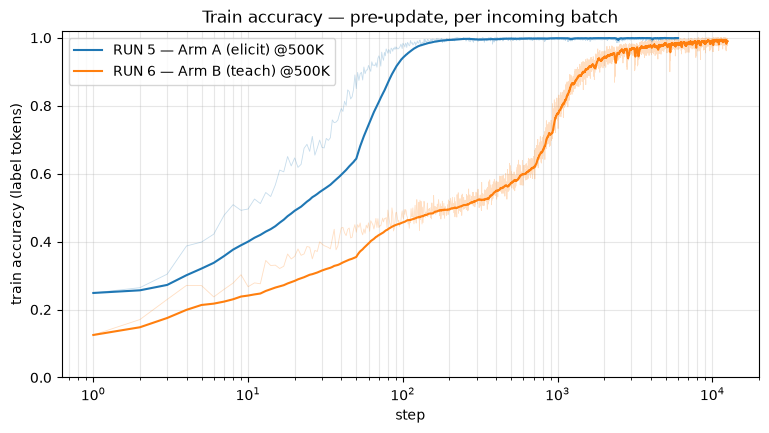

In [16]:
# Per-step train accuracy (token-level, pre-update, same batches as the loss
# above). Complements the loss view: A should sit near 1.0 almost immediately
# (algorithm known, notation remap only), B should trace a full S-curve.
fig, ax = plt.subplots(figsize=(9, 4.5))
for (label, r), color in zip(runs.items(), colors):
    t = r["train"]
    ax.plot(t["step"], t["train_accuracy"], color=color, alpha=0.25, lw=0.6)
    ax.plot(t["step"], t["train_accuracy"].rolling(50, min_periods=1).mean(),
            color=color, label=label)
ax.set(xlabel="step", ylabel="train accuracy (label tokens)", xscale="log",
       ylim=(0, 1.02), title="Train accuracy — pre-update, per incoming batch")
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.show()

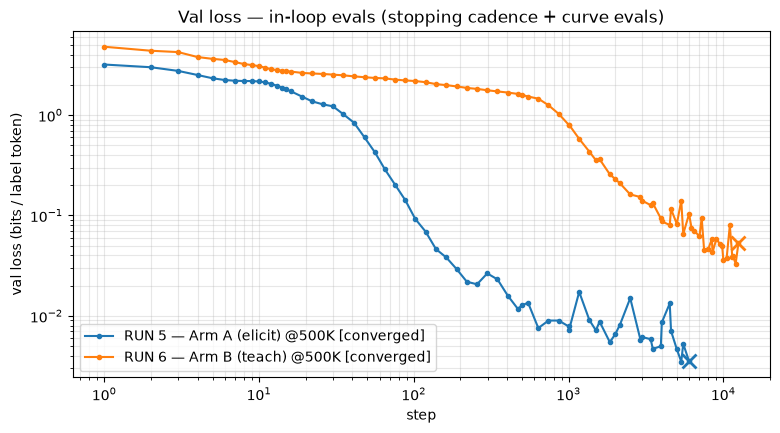

In [17]:
# Held-out val loss (in-loop evals). "x" marks each run's last eval. Log-log:
# runs launched after 2026-07-22 also log dense curve evals at log-spaced
# early steps (stopping_eval: false rows — never fed to the ε/k rule), which
# fill the early decades; the pilots only have the every-500 cadence.
fig, ax = plt.subplots(figsize=(9, 4.5))
for (label, r), color in zip(runs.items(), colors):
    v = r["val"]
    bits = v["val_loss_nats"].map(nats_to_bits)
    stop = r["result"].get("stop_reason") or "running"
    ax.plot(v["step"], bits, color=color, marker="o", ms=3, label=f"{label} [{stop}]")
    ax.plot(v["step"].iloc[-1], bits.iloc[-1], color=color, marker="x", ms=10, mew=2)
ax.set(xlabel="step", ylabel="val loss (bits / label token)",
       xscale="log", yscale="log",
       title="Val loss — in-loop evals (stopping cadence + curve evals)")
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.show()


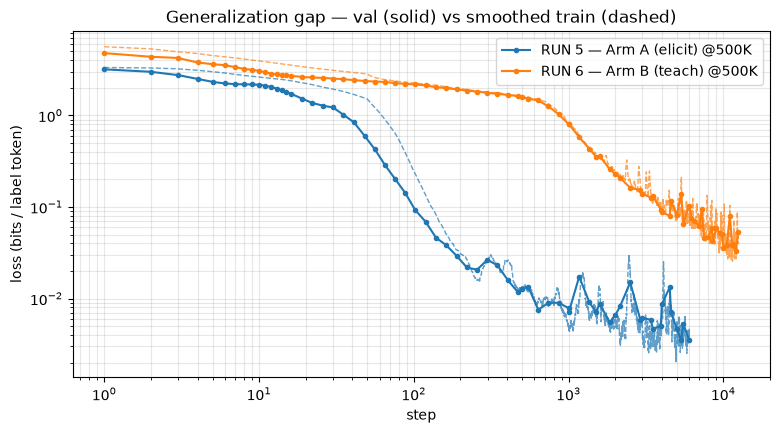

In [18]:
# Generalization gap: held-out val loss (solid) vs smoothed train loss
# (dashed) on shared axes. With question-disjoint splits these should track
# each other closely; a val curve sitting well above train = memorizing
# D_target specifics rather than the algorithm.
fig, ax = plt.subplots(figsize=(9, 4.5))
for (label, r), color in zip(runs.items(), colors):
    t, v = r["train"], r["val"]
    ax.plot(t["step"],
            t["train_loss_nats"].map(nats_to_bits).rolling(50, min_periods=1).mean(),
            color=color, lw=1, ls="--", alpha=0.7)
    ax.plot(v["step"], v["val_loss_nats"].map(nats_to_bits), color=color,
            marker="o", ms=3, label=label)
ax.set(xlabel="step", ylabel="loss (bits / label token)", xscale="log", yscale="log",
       title="Generalization gap — val (solid) vs smoothed train (dashed)")
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.show()

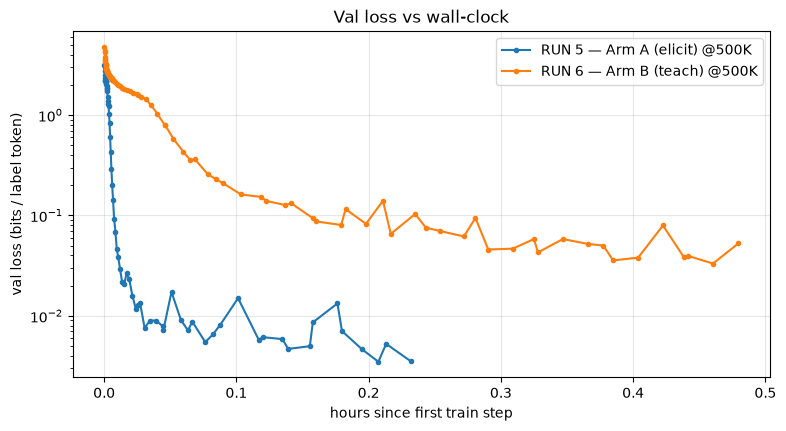

In [19]:
# Same val curves against wall-clock instead of steps — what convergence cost
# in box-hours. Steps are comparable across arms (identical recipe); hours add
# the throughput reality (eval pauses, snapshot writes).
fig, ax = plt.subplots(figsize=(9, 4.5))
for (label, r), color in zip(runs.items(), colors):
    v = r["val"]
    hours = (v["time_unix"] - r["train"]["time_unix"].iloc[0]) / 3600
    ax.plot(hours, v["val_loss_nats"].map(nats_to_bits), color=color,
            marker="o", ms=3, label=label)
ax.set(xlabel="hours since first train step", ylabel="val loss (bits / label token)",
       yscale="log", title="Val loss vs wall-clock")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

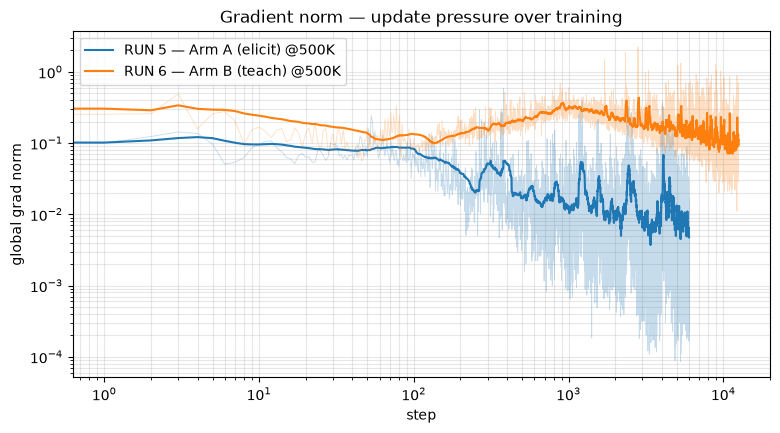

In [20]:
# Global gradient norm per step (logs/gradstats.jsonl). Reads as "how much
# update pressure D_target still exerts": A should decay to noise quickly,
# B should stay elevated while the algorithm is written into the adapters.
fig, ax = plt.subplots(figsize=(9, 4.5))
for (label, r), color in zip(runs.items(), colors):
    g = r["grad"]
    if g is None:
        print(f"{label}: no logs/gradstats.jsonl — skipped")
        continue
    ax.plot(g["step"], g["global_grad_norm"], color=color, alpha=0.25, lw=0.6)
    ax.plot(g["step"], g["global_grad_norm"].rolling(50, min_periods=1).mean(),
            color=color, label=label)
ax.set(xlabel="step", ylabel="global grad norm", xscale="log", yscale="log",
       title="Gradient norm — update pressure over training")
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.show()

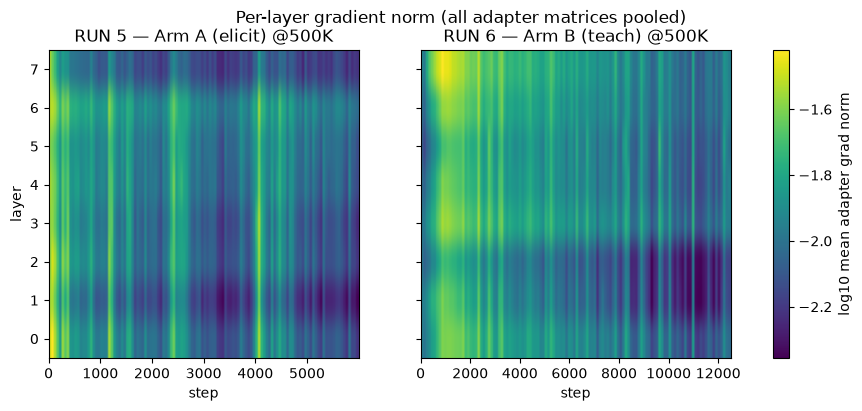

In [21]:
# Where in the network the gradient lands: mean adapter grad norm per layer
# (A+B matrices of all target modules pooled), time-binned. If elicitation is
# a notation remap, A's gradient should concentrate in fewer layers; teaching
# should spread deeper/wider (cf. Wang et al.'s constant-shift picture).
with_grad = [(label, r) for label, r in runs.items() if r["grad"] is not None]
fig, axes = plt.subplots(1, len(with_grad), figsize=(5.5 * len(with_grad), 4),
                         sharey=True, squeeze=False)
for axi, (label, r) in zip(axes[0], with_grad):
    g = r["grad"]
    per_mod = pd.DataFrame(list(g["per_module_grad_norm"]))
    layer_of = {c: int(re.search(r"layers\.(\d+)\.", c).group(1)) for c in per_mod.columns}
    per_layer = per_mod.T.groupby(layer_of).mean().T  # step x layer
    edges = np.linspace(0, len(per_layer), 121, dtype=int)  # ~120 time bins
    binned = np.stack([per_layer.iloc[a:b].mean().to_numpy()
                       for a, b in zip(edges[:-1], edges[1:]) if b > a])
    im = axi.imshow(np.log10(binned.T + 1e-12), aspect="auto", origin="lower",
                    cmap="viridis",
                    extent=(g["step"].iloc[0], g["step"].iloc[-1],
                            -0.5, per_layer.shape[1] - 0.5))
    axi.set(xlabel="step", title=label, ylabel="layer" if axi is axes[0][0] else None)
fig.colorbar(im, ax=list(axes[0]), label="log10 mean adapter grad norm")
fig.suptitle("Per-layer gradient norm (all adapter matrices pooled)")
plt.show()

## §2 EDL / MDL — the bits-that-count comparison

The paper's quantities (Donoway et al.): the epoch-1 prequential learning
curve, its cumulative codelength (= MDL of D_target under the online code),
the running excess over the converged model's ideal code (EDL = MDL − N·θ_T),
normalizations (EDL/D per label token, EDL/P per trainable adapter param),
sample efficiency, G5 behavioral evidence, and how the totals scale with n
across the OPEN(2) pilots. Stored in nats, converted to bits only for display.

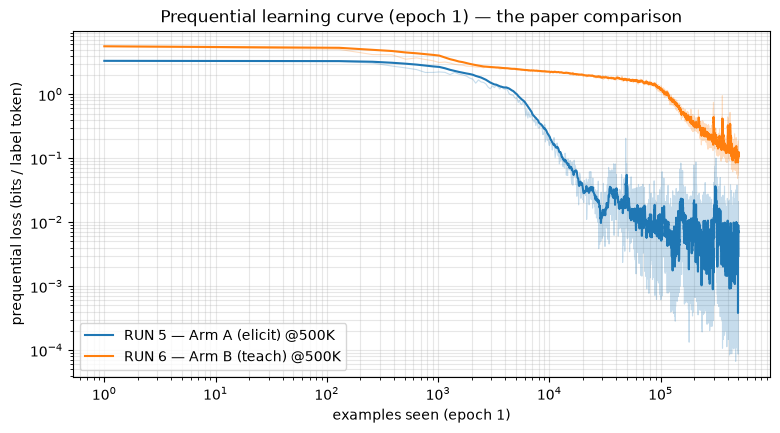

In [22]:
# The paper-shaped curve: epoch-1 prequential loss per label token vs. examples
# seen (each point is a batch's PRE-update loss — loss on data never seen
# before). This is the panel to hold against Donoway et al.: A should start low
# (algorithm already known, only notation to remap) and flatline within few
# examples; B should trace a full learning curve.
fig, ax = plt.subplots(figsize=(9, 4.5))
for (label, r), color in zip(runs.items(), colors):
    if r["curve"] is None:
        print(f"{label}: no logs/prequential.jsonl yet (run not finished) — skipped")
        continue
    c = r["curve"]
    x = c["example_index"] + 1  # +1 so the first batch survives the log axis
    bits = c["loss_per_label_token_nats"].map(nats_to_bits)
    ax.plot(x, bits, color=color, alpha=0.25, lw=0.8)
    ax.plot(x, bits.rolling(9, min_periods=1).mean(), color=color, label=label)
ax.set(xlabel="examples seen (epoch 1)", ylabel="prequential loss (bits / label token)",
       xscale="log", yscale="log",
       title="Prequential learning curve (epoch 1) — the paper comparison")
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.show()


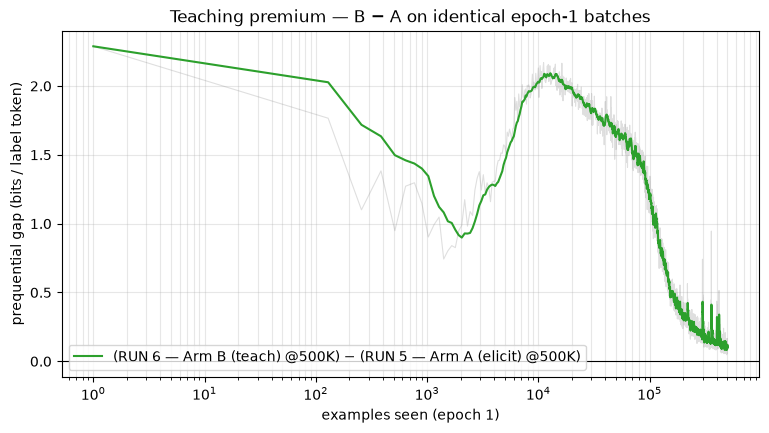

In [23]:
# Teaching premium per batch: B − A prequential loss on the SAME examples in
# the SAME order (G7 pins data_order_hash, so epoch-1 batches align
# one-to-one). Positive gap = extra bits B pays on that batch because the
# algorithm isn't already latent; the area under it is EDL_B − EDL_A up to
# the θ_T difference. Uses the first two RUNS entries (A, B).
first_two = list(runs)[:2]
if len(first_two) == 2 and all(runs[k]["curve"] is not None for k in first_two):
    a, b = (runs[k]["curve"] for k in first_two)
    k = min(len(a), len(b))
    gap_bits = (b["loss_per_label_token_nats"].to_numpy()[:k]
                - a["loss_per_label_token_nats"].to_numpy()[:k]) / LN2
    x = a["example_index"].to_numpy()[:k] + 1
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.axhline(0, color="k", lw=0.8)
    ax.plot(x, gap_bits, color="gray", alpha=0.25, lw=0.8)
    ax.plot(x, pd.Series(gap_bits).rolling(9, min_periods=1).mean().to_numpy(),
            color=colors[2], label=f"({first_two[1]}) − ({first_two[0]})")
    ax.set(xlabel="examples seen (epoch 1)", xscale="log",
           ylabel="prequential gap (bits / label token)",
           title="Teaching premium — B − A on identical epoch-1 batches")
    ax.grid(alpha=0.3, which="both")
    ax.legend()
    plt.show()
else:
    print("needs the first two RUNS entries (A, B) with prequential logs — skipped")

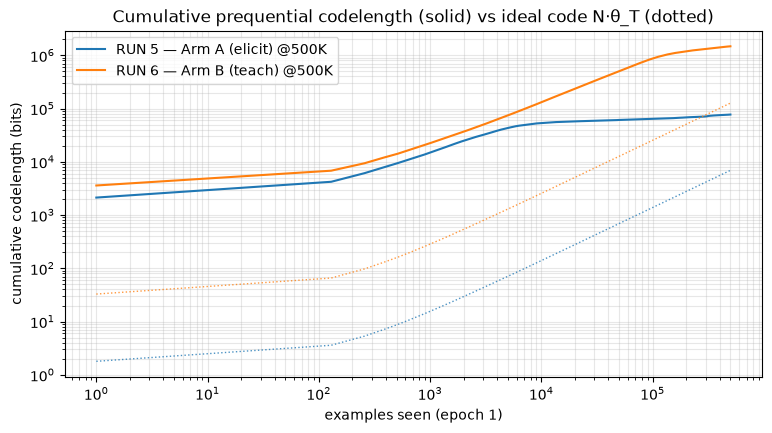

In [24]:
# Cumulative prequential codelength (epoch 1): total bits spent to transmit
# the first n examples' labels under the online code — the endpoint is MDL.
# Dotted: the converged model's ideal code (cumulative label tokens × θ_T),
# the floor a model that already knew the task would pay.
fig, ax = plt.subplots(figsize=(9, 4.5))
for (label, r), color in zip(runs.items(), colors):
    if r["curve"] is None:
        print(f"{label}: no logs/prequential.jsonl — skipped")
        continue
    c = r["curve"]
    x = c["example_index"].to_numpy() + 1
    ax.plot(x, c["loss_sum_nats"].cumsum().to_numpy() / LN2, color=color, label=label)
    if r["theta_T_nats"] is not None:
        floor = c["label_token_count"].cumsum().to_numpy() * r["theta_T_nats"] / LN2
        ax.plot(x, floor, color=color, ls=":", lw=1, alpha=0.8)
ax.set(xlabel="examples seen (epoch 1)", ylabel="cumulative codelength (bits)",
       xscale="log", yscale="log",
       title="Cumulative prequential codelength (solid) vs ideal code N·θ_T (dotted)")
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.show()

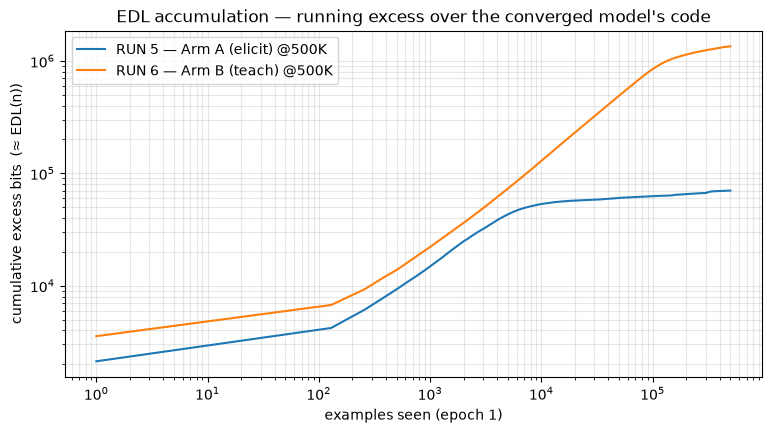

In [25]:
# EDL accumulation: cumulative codelength minus the ideal code — the running
# excess description length. Where a curve flatlines, that arm has stopped
# paying for the task; the plateau height approximates its EDL. A should
# plateau within the first decades; B should keep climbing for most of epoch 1.
fig, ax = plt.subplots(figsize=(9, 4.5))
for (label, r), color in zip(runs.items(), colors):
    if r["curve"] is None or r["theta_T_nats"] is None:
        print(f"{label}: needs prequential log + eval/test_loss.json — skipped")
        continue
    c = r["curve"]
    x = c["example_index"].to_numpy() + 1
    excess_bits = (c["loss_sum_nats"].cumsum().to_numpy()
                   - c["label_token_count"].cumsum().to_numpy() * r["theta_T_nats"]) / LN2
    ax.plot(x, excess_bits, color=color, label=label)
ax.set(xlabel="examples seen (epoch 1)", ylabel="cumulative excess bits  (≈ EDL(n))",
       xscale="log", yscale="log",
       title="EDL accumulation — running excess over the converged model's code")
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.show()

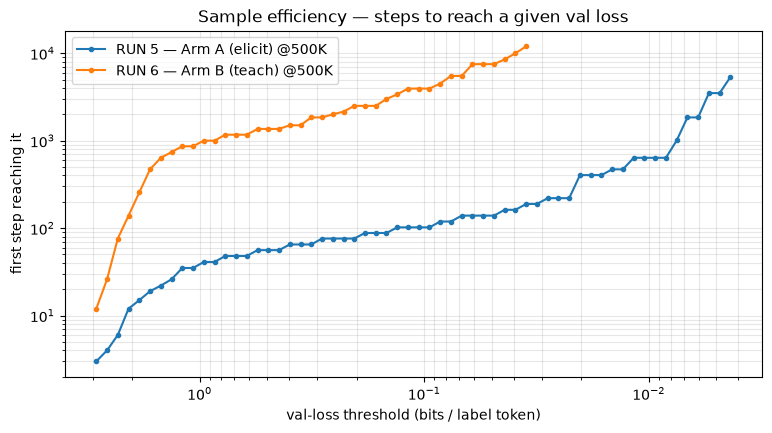

In [26]:
# Sample efficiency: first training step at which val loss drops below a
# threshold, swept across thresholds (using the running min over all val
# evals, incl. the dense early curve evals). The vertical gap between curves
# is the elicit-vs-teach speedup at that quality level; a curve that stops
# short never reached that threshold before its ε/k stop.
fig, ax = plt.subplots(figsize=(9, 4.5))
thresholds = np.logspace(np.log10(2.0), np.log10(0.003), 60)  # nats
for (label, r), color in zip(runs.items(), colors):
    v = r["val"].sort_values("step")
    best = v["val_loss_nats"].cummin().to_numpy()
    steps = v["step"].to_numpy()
    first = [steps[np.argmax(best <= th)] if (best <= th).any() else np.nan
             for th in thresholds]
    ax.plot(thresholds / LN2, first, color=color, marker=".", label=label)
ax.set(xlabel="val-loss threshold (bits / label token)",
       ylabel="first step reaching it", xscale="log", yscale="log",
       title="Sample efficiency — steps to reach a given val loss")
ax.invert_xaxis()  # reading left -> right = demanding more quality
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.show()

In [27]:
# MDL / EDL totals and normalizations. EDL = MDL − N·θ_T needs the finalized
# run (eval/test_loss.json + masking-hash parity) — "n/a" until then.
# EDL/D = per epoch-1 label token; EDL/P = per trainable adapter parameter.
rows = []
for label, r in runs.items():
    rid = r["id"]
    row = {"run": label, "run_id": rid}
    try:
        row["MDL_bits"] = nats_to_bits(mdl_nats(rid, store=STORE))
    except FileNotFoundError:
        row["MDL_bits"] = None
    for col, fn in [("EDL_bits", edl_nats), ("EDL/D_bits", edl_per_label_token),
                    ("EDL/P_bits", edl_per_param)]:
        try:
            row[col] = nats_to_bits(fn(rid, store=STORE))
        except Exception as e:  # incomplete run / missing test loss / hash mismatch
            row[col] = f"n/a ({type(e).__name__})"
    row["theta_T_bits"] = None if r["theta_T_nats"] is None else nats_to_bits(r["theta_T_nats"])
    rows.append(row)
df = pd.DataFrame(rows)
ab = df["EDL_bits"].iloc[:2]
if len(ab) == 2 and all(isinstance(v, float) for v in ab):
    print(f"EDL ratio (row 1 / row 0): {ab.iloc[1] / ab.iloc[0]:.1f}x")
df

EDL ratio (row 1 / row 0): 19.2x


,run,run_id,MDL_bits,EDL_bits,EDL/D_bits,EDL/P_bits,theta_T_bits
0,RUN 5 — Arm A (elicit) @500K,evt-run5-armA-target,7.714206e+04,7.022933e+04,0.028478,0.005824,0.002803
1,RUN 6 — Arm B (teach) @500K,evt-run6-armB-target,1.476010e+06,1.349421e+06,0.547192,0.111905,0.051332


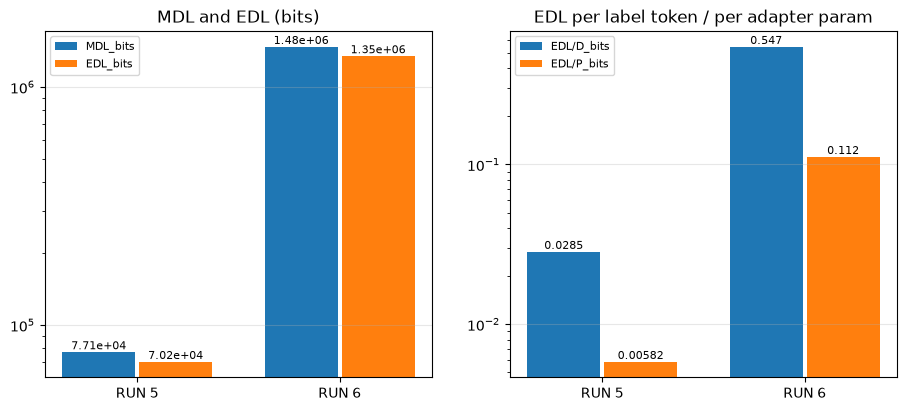

In [28]:
# The headline numbers as bars (log scale — the whole point is orders of
# magnitude). Left: raw MDL and EDL. Right: normalized EDL/D and EDL/P.
num = df[df["EDL_bits"].apply(lambda v: isinstance(v, float))]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
x = np.arange(len(num))
for ax, cols, title in [
    (axes[0], ["MDL_bits", "EDL_bits"], "MDL and EDL (bits)"),
    (axes[1], ["EDL/D_bits", "EDL/P_bits"], "EDL per label token / per adapter param"),
]:
    for i, col in enumerate(cols):
        bars = ax.bar(x + (i - 0.5) * 0.38, num[col].astype(float), width=0.36, label=col)
        ax.bar_label(bars, fmt="%.3g", fontsize=8)
    ax.set(title=title, yscale="log", xticks=x,
           xticklabels=[label.split("—")[0].strip() for label in num["run"]])
    ax.grid(alpha=0.3, axis="y")
    ax.legend(fontsize=8)
plt.show()

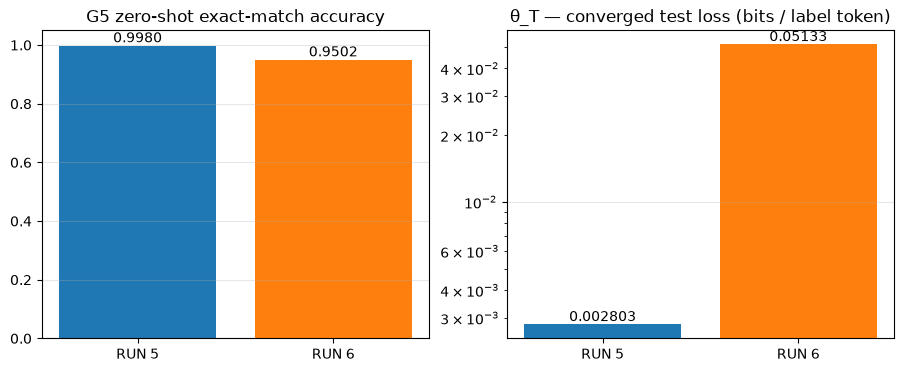

In [29]:
# G5 evidence next to the information cost: behavioral accuracy (zero-shot,
# greedy, exact-match) and the converged test loss θ_T. 16-shot is omitted —
# that metric is invalidated for these arms (decisions.md). Evidence only,
# no pass bar.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
names = [label.split("—")[0].strip() for label in runs]
acc = [np.nan if r["g5"].get("zero_shot_accuracy") is None
       else r["g5"]["zero_shot_accuracy"] for r in runs.values()]
theta = [np.nan if r["theta_T_nats"] is None else nats_to_bits(r["theta_T_nats"])
         for r in runs.values()]
b0 = axes[0].bar(names, acc, color=colors[: len(runs)])
axes[0].bar_label(b0, fmt="%.4f")
axes[0].set(title="G5 zero-shot exact-match accuracy", ylim=(0, 1.05))
b1 = axes[1].bar(names, theta, color=colors[: len(runs)])
axes[1].bar_label(b1, fmt="%.4g")
axes[1].set(title="θ_T — converged test loss (bits / label token)", yscale="log")
for ax in axes:
    ax.grid(alpha=0.3, axis="y")
plt.show()

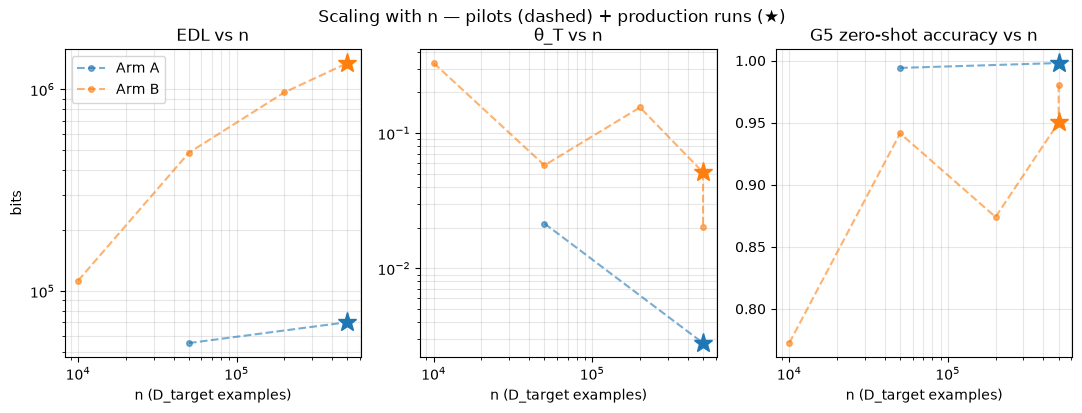

,run_id,arm,n,pilot,theta_T_bits,G5_zero_shot,EDL_bits
0,evt-run5-pilot-n50k,A,50000,True,0.021469,0.994141,5.534931e+04
1,evt-run5-armA-target,A,500000,False,0.002803,0.998047,7.022933e+04
2,evt-run6-pilot-n10k,B,10000,True,0.330234,0.772461,1.127398e+05
3,evt-run6-pilot-n50k,B,50000,True,0.057829,0.941406,4.853336e+05
4,evt-run6-pilot-n200k,B,200000,True,0.155139,0.874023,9.654829e+05
5,evt-run6-armB-target,B,500000,False,0.051332,0.950195,1.349421e+06
6,evt-run6-pilot-n500k,B,500000,True,0.020270,0.980469,1.341809e+06


In [30]:
# Scaling with n — every finished target/pilot run in the store, regardless
# of the RUNS selection above. This is the OPEN(2) grid view: B's EDL / θ_T /
# G5 accuracy vs n, with A's points for contrast. The stop-wobble caveat
# (decisions.md 2026-07-22) applies to any single point.
recs = []
for mp in sorted((STORE / "runs").glob("*/manifest.json")):
    m = json.loads(mp.read_text())
    e = m.get("experiment") or {}
    if e.get("role") != "target" or not (e.get("target_result") or {}).get("final_step"):
        continue
    rid = mp.parent.name
    tl = mp.parent / "eval" / "test_loss.json"
    g5 = ((e.get("gates") or {}).get("G5") or {}).get("zero_shot_accuracy")
    rec = {
        "run_id": rid,
        "arm": e.get("arm") or ("A" if "armA" in rid else "B"),
        "n": e.get("n_examples", np.nan),
        "pilot": "pilot" in rid,
        "theta_T_bits": nats_to_bits(json.loads(tl.read_text())["loss_per_label_token_nats"])
        if tl.exists() else np.nan,
        "G5_zero_shot": np.nan if g5 is None else g5,
    }
    try:
        rec["EDL_bits"] = nats_to_bits(edl_nats(rid, store=STORE))
    except Exception:
        rec["EDL_bits"] = np.nan
    recs.append(rec)
scale = pd.DataFrame(recs).sort_values(["arm", "n"]).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True)
for ax, col, title in zip(
    axes,
    ["EDL_bits", "theta_T_bits", "G5_zero_shot"],
    ["EDL vs n", "θ_T vs n", "G5 zero-shot accuracy vs n"],
):
    for arm, color in [("A", colors[0]), ("B", colors[1])]:
        s = scale[scale["arm"] == arm]
        ax.plot(s["n"], s[col], color=color, marker="o", ms=4, ls="--", alpha=0.6,
                label=f"Arm {arm}")
        prod = s[~s["pilot"]]
        ax.plot(prod["n"], prod[col], color=color, marker="*", ms=14, ls="none")
    ax.set(title=title, xlabel="n (D_target examples)", xscale="log")
    if col != "G5_zero_shot":
        ax.set_yscale("log")
    ax.grid(alpha=0.3, which="both")
axes[0].set_ylabel("bits")
axes[0].legend()
fig.suptitle("Scaling with n — pilots (dashed) + production runs (★)")
plt.show()
scale

## How to read this

**Paper-consistent (what we need):**
- Arm A's prequential curve starts well below B's and flatlines within few
  examples; B traces a slower learning curve across many more examples.
- EDL_A ≪ EDL_B (elicitation reveals a latent capability cheaply; teaching pays
  for the algorithm in full).
- Both arms' val loss converges near zero — the ε/k rule fired (`stop_reason=
  converged`), so both endpoints actually learned the task.

**Trouble signs:**
1. **Curves overlap (EDL_A ≈ EDL_B)** — the run-2 algorithm pre-teach conferred
   no head start: at 38.7M there is no latent-capability contrast between the
   arms, and the elicit-vs-teach comparison has no signal to measure.
2. **A at or above B, or A not converging** — cross-notation transfer failed
   (the algorithm was taught in NL notation but doesn't carry to operator
   notation), pointing at the run-3 installer or the pre-teach itself.
3. **`stop_reason=max_steps` on either arm** — the run never converged;
   investigate before reading anything else off these plots.

**Production caveat (stop wobble, decisions.md 2026-07-22):** run 6's ε/k stop
undershot its *same-seed* pilot (stop 12,500 / min-val 0.0230 nats vs the
B@500K pilot's 15,500 / 0.0140) — GPU nondeterminism + ε/k noise sensitivity
in B's shallow tail. Quote the θ_T / test-loss gap (18×) *with* this caveat;
the prequential curves, not the endpoints, are the primary measurement.

Grid context: add the other `open2_b` run_ids to `RUNS` to see how B's curves
move with n — the OPEN(2) verdict itself is the G5 accuracy comparison.
